# 3. Análise Exploratória dos Dados (EDA)

Nesta etapa, vou explorar a base de dados para entender quais fatores podem estar relacionados à satisfação do cliente. Não olhando apenas para números ou gráficos separados, mas tentar responder perguntas que ajudem a entender melhor a experiência do cliente no e-commerce.

Como o projeto fala sobre NPS, vou observar principalmente pontos da jornada que podem afetar a percepção do cliente, como atraso na entrega, contato com o atendimento, reclamações, tempo de resolução e recompra.

As perguntas que vão guiar essa análise são:

1. Clientes com atraso na entrega parecem dar notas menores de NPS?
2. O tempo total de entrega pode influenciar a satisfação?
3. Muitos contatos com atendimento parecem estar ligados a notas mais baixas?
4. Reclamações e maior tempo de resolução podem estar relacionados a mais clientes detratores?
5. Existe algum ponto em que a experiência parece piorar bastante, como muitos dias de atraso ou muitos contatos com atendimento?
6. Clientes que recompraram em até 30 dias parecem ter NPS mais alto?
7. Existem diferenças relevantes por região, idade ou tempo de relacionamento com a empresa?

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/desafio_nps_fase_1.csv")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [2]:
# Tamanho da base
df.shape

(2500, 19)

In [3]:
# Informações da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [4]:
# Verificando se tem dados duplicados
df.duplicated().sum()

np.int64(0)

A base não possui registros duplicados.

In [5]:
# Verificando a distribuição do NPS
df["nps_score"].describe()

count    2500.000000
mean        4.378600
std         2.510229
min         0.000000
25%         2.600000
50%         4.400000
75%         6.100000
max        10.000000
Name: nps_score, dtype: float64

A média do `nps_score` ficou em aproximadamente **4,38** e a mediana em **4,40**. Isso mostra que, nessa base, as notas estão mais concentradas em valores baixos ou intermediários.

Também é possível observar que 75% das notas estão até **6,10**. Então, antes de olhar outras variáveis, parece existir uma quantidade relevante de clientes com uma percepção não tão positiva.

In [6]:
# Classificando os NPS em grupos, sendo até 6 como Detrator, de 6 a 8 como Neutro e acima de 8 como Promotor
def classificar_nps(nota):
    if nota <= 6:
        return "Detrator"
    elif nota <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["nps_group"] = df["nps_score"].apply(classificar_nps)

df["nps_group"].value_counts()

nps_group
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64

Ao classificar os clientes em **detratores**, **neutros** e **promotores**, a maior parte ficou no grupo de **detratores**. Dos 2500 registros, **1851** clientes deram nota de 0 a 6, enquanto **448** ficaram como **neutros** e apenas **201** como **promotores**.

In [7]:
df["nps_group"].value_counts(normalize=True) * 100

nps_group
Detrator    74.04
Neutro      17.92
Promotor     8.04
Name: proportion, dtype: float64

Ao transformar o NPS em grupos, a maior parte dos clientes ficou como **detrator**. Cerca de **74%** dos registros estão nesse grupo, enquanto **17,92%** são neutros e apenas **8,04%** são promotores.

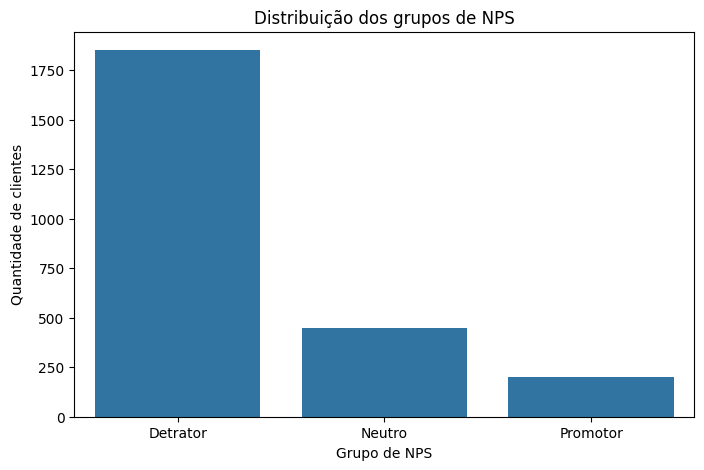

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="nps_group",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Distribuição dos grupos de NPS")
plt.xlabel("Grupo de NPS")
plt.ylabel("Quantidade de clientes")
plt.show()

O gráfico reforça que a maior parte dos clientes está no grupo de **detratores**. Então existe uma concentração grande de clientes com notas mais baixas de NPS.

## Atraso na Entrega
### Quais fatores parecem mais críticos para a satisfação?

In [9]:
# Criando uma variável para indicar se o pedido teve atraso na entrega
df["has_delivery_delay"] = df["delivery_delay_days"].apply(
    lambda x: "Com atraso" if x > 0 else "Sem atraso" # Se delivery_delay_days for maior que 0, considero que houve atraso
)

df["has_delivery_delay"].value_counts()

has_delivery_delay
Com atraso    2223
Sem atraso     277
Name: count, dtype: int64

A maioria dos pedidos da base aparece como **com atraso**. Dos 2500 registros, 2223 tiveram pelo menos 1 dia de atraso, enquanto apenas 277 não tiveram atraso.

Isso mostra que o atraso é um ponto importante na análise.

In [10]:
# Relacionando pedidos com atraso e sem atraso e o NPS médio de cada um deles
df.groupby("has_delivery_delay")["nps_score"].mean().sort_values()

has_delivery_delay
Com atraso    4.069816
Sem atraso    6.856679
Name: nps_score, dtype: float64

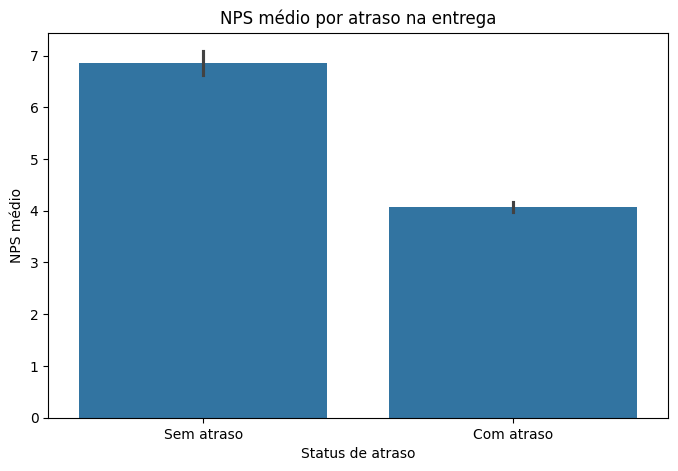

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="has_delivery_delay",
    y="nps_score",
    order=["Sem atraso", "Com atraso"]
)

plt.title("NPS médio por atraso na entrega")
plt.xlabel("Status de atraso")
plt.ylabel("NPS médio")
plt.show()

Comparando o NPS médio entre pedidos com atraso e sem atraso, dá para perceber que os clientes **sem atraso** tiveram NPS médio de aproximadamente **6,86**, enquanto os clientes **com atraso** tiveram média de aproximadamente **4,07**.

Isso mostra que o atraso na entrega pode estar ligado a uma nota baixa na experiência do cliente. Ainda não dá para afirmar que o atraso é a única causa dessas notas, porque outros pontos na jornada de compra também podem influenciar.

In [12]:
df["delivery_delay_days"].describe()

count    2500.000000
mean        2.187200
std         1.454442
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: delivery_delay_days, dtype: float64

Os dias de atraso variam de 0 a 8 dias. A média ficou em aproximadamente **2,18 dias** e a mediana em **2 dias**, então boa parte dos pedidos com atraso parece estar concentrada em atrasos pequenos ou moderados.

Também dá para observar que 75% dos pedidos têm **até 3 dias de atraso**. Mesmo assim, existem casos com atrasos maiores, chegando a **8 dias**.

In [13]:
# Criando faixas de atraso para facilitar a comparação com o NPS

def classificar_atraso(dias):
    if dias == 0:
        return "Sem atraso"
    elif dias <= 2:
        return "Atraso baixo (1-2 dias)"
    elif dias <= 4:
        return "Atraso moderado (3-4 dias)"
    else:
        return "Atraso alto (5+ dias)"

df["delivery_delay_group"] = df["delivery_delay_days"].apply(classificar_atraso)

df.groupby("delivery_delay_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
delivery_delay_group,,
Sem atraso,277,6.856679
Atraso baixo (1-2 dias),1261,5.051308
Atraso moderado (3-4 dias),795,3.099748
Atraso alto (5+ dias),167,1.276647


Separando os atrasos em faixas, dá para perceber que o NPS médio diminui conforme o atraso aumenta. Os pedidos **sem atraso** tiveram a maior média de NPS, enquanto os pedidos com **atraso alto** tiveram a menor média.

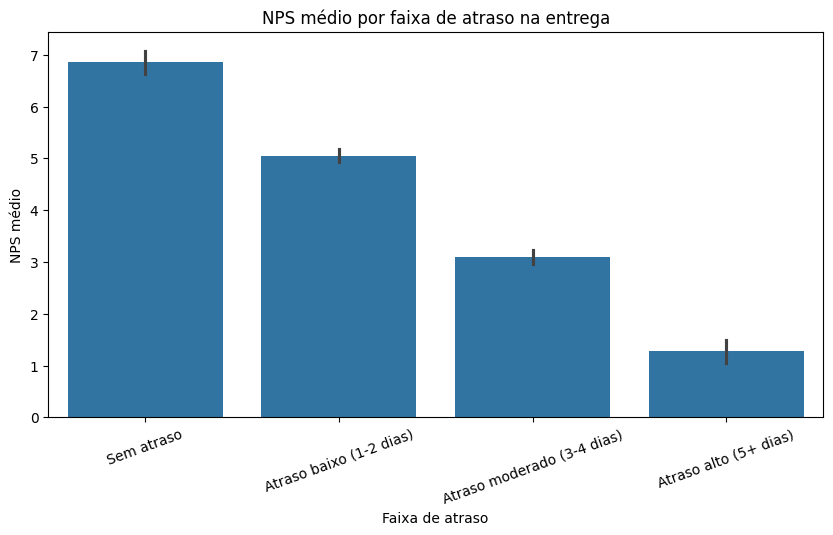

In [14]:
ordem_atraso = [
    "Sem atraso",
    "Atraso baixo (1-2 dias)",
    "Atraso moderado (3-4 dias)",
    "Atraso alto (5+ dias)"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="delivery_delay_group",
    y="nps_score",
    order=ordem_atraso
)

plt.title("NPS médio por faixa de atraso na entrega")
plt.xlabel("Faixa de atraso")
plt.ylabel("NPS médio")
plt.xticks(rotation=20)
plt.show()

### Ponto de Ruptura
A queda entre o atraso baixo (1 a 2 dias) e o atraso moderado (3 a 4 dias) cai bastante. Isso pode indicar que, depois de alguns dias de atraso, a nota do cliente piora bastante.

Então atrasos maiores podem ser um **ponto de ruptura** importante na experiência do cliente.

## Contato com o Atendimento
### Quais fatores parecem mais críticos para a satisfação?

In [15]:
# Verificando a distribuição da quantidade de contatos com o atendimento
df["customer_service_contacts"].describe()

count    2500.000000
mean        1.519600
std         1.231512
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: customer_service_contacts, dtype: float64

A quantidade de contatos com atendimento varia de 0 a 7. A média ficou em aproximadamente **1,52 contato** e a mediana em **1 contato**, então muitos clientes parecem ter entrado em contato poucas vezes com o suporte.

Também dá para observar que 75% dos clientes tiveram **até 2 contatos** com atendimento. Mesmo assim, existem casos com mais contatos, chegando a **7**.

Por isso, vale comparar o NPS entre clientes que não precisaram de atendimento, clientes com poucos contatos e clientes com muitos contatos, para entender se essa variável parece estar ligada à satisfação.

In [16]:
# Criando grupos para a quantidade de contatos com atendimento
def classificar_contatos(qtd):
    if qtd == 0:
        return "Nenhum contato"
    elif qtd <= 2:
        return "Poucos contatos (1-2)"
    else:
        return "Muitos contatos (3+)"

df["service_contacts_group"] = df["customer_service_contacts"].apply(classificar_contatos)

# Calculando a quantidade de clientes e o NPS médio para cada grupo
df.groupby("service_contacts_group")["nps_score"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
service_contacts_group,,
Nenhum contato,554,5.543502
Poucos contatos (1-2),1456,4.419437
Muitos contatos (3+),490,2.940204
